# DoE de punta a punta en química: optimización de una reacción

**Caso:** maximizar el *rendimiento* (%) de una reacción catalítica que depende de
cuatro factores de proceso: **temperatura** (°C), **pH**, **concentración de
catalizador** (mol/L) y **tiempo** (min). Tenemos presupuesto para pocos
experimentos, así que seguimos el embudo clásico de *Design of Experiments*:

> **screening** (¿qué factores importan?) → **superficie de respuesta**
> (¿dónde está el óptimo?) → **evaluación** (¿qué tan bueno es mi diseño?).

Lo que hace especial a este cuaderno: usamos una **función-verdad conocida** para
simular el laboratorio. Eso nos permite *benchmarkear* el propio DoE — medir qué
tan cerca del óptimo real llegamos y compararlo con muestreo aleatorio del mismo
tamaño. Ese es el diferenciador de `doekit`: no solo construir el diseño, sino
**certificar su calidad**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import doekit as ed
from doekit import plotting

rng = np.random.default_rng(7)
plt.rcParams["figure.dpi"] = 110

# --- Factores del proceso (unidades naturales) ---
factores = {
    "temp": (20.0, 80.0),   # C
    "pH":   (3.0, 9.0),
    "cat":  (0.1, 0.5),     # mol/L
    "tiempo": (10.0, 60.0), # min
}
print("Factores:", list(factores))


Factores: ['temp', 'pH', 'cat', 'tiempo']


## 1. La "verdad" del laboratorio (solo para benchmarking)

En un experimento real esta función es desconocida: es la naturaleza. Aquí la
definimos para poder medir qué tan bien la recupera el DoE. En **espacio
codificado** (`-1 = nivel bajo`, `+1 = nivel alto`) el rendimiento verdadero es
una superficie cuadrática con un óptimo interior, más ruido experimental:

- la temperatura y el pH tienen un óptimo (curvatura negativa) y **interactúan**;
- la concentración de catalizador tiene su propio óptimo;
- el **tiempo es casi irrelevante** (un buen screening debería descartarlo).


In [2]:
FACS = ed.as_factors(factores)         # lista de ContinuousFactor
_enc = {f.name: f for f in FACS}

def _codificar(df):
    X = np.column_stack([_enc[n].encode(df[n].to_numpy()) for n in factores])
    return X  # columnas xT, xpH, xC, xt en [-1, 1]

# Coeficientes verdaderos (desconocidos en la practica)
BETA = dict(base=80.0, T=6.0, pH=5.0, C=4.0, t=0.3,
            TT=-8.0, pHpH=-7.0, CC=-5.0, TpH=3.0)

def rendimiento_verdadero(df, ruido=2.0, seed=None):
    r = np.random.default_rng(seed)
    xT, xpH, xC, xt = _codificar(df).T
    y = (BETA["base"] + BETA["T"]*xT + BETA["pH"]*xpH + BETA["C"]*xC + BETA["t"]*xt
         + BETA["TT"]*xT**2 + BETA["pHpH"]*xpH**2 + BETA["CC"]*xC**2
         + BETA["TpH"]*xT*xpH)
    return y + r.normal(0, ruido, size=len(df))

# Optimo verdadero (resuelto sobre la superficie sin ruido, dentro de [-1,1])
from scipy.optimize import minimize
def _neg(xc):
    xc = np.clip(xc, -1, 1)
    xT, xpH, xC, xt = xc
    return -(BETA["base"] + BETA["T"]*xT + BETA["pH"]*xpH + BETA["C"]*xC + BETA["t"]*xt
             + BETA["TT"]*xT**2 + BETA["pHpH"]*xpH**2 + BETA["CC"]*xC**2 + BETA["TpH"]*xT*xpH)
opt = minimize(_neg, x0=[0,0,0,0], bounds=[(-1,1)]*4)
X_OPT_COD = opt.x
Y_OPT = -opt.fun
print("Optimo verdadero (codificado):", np.round(X_OPT_COD, 3))
print("Rendimiento maximo verdadero:  %.1f %%" % Y_OPT)


Optimo verdadero (codificado): [0.46  0.456 0.4   1.   ]
Rendimiento maximo verdadero:  83.6 %


## 2. Fase 1 — Screening: ¿qué factores importan?

Con 4 factores usamos un **factorial fraccional** `2^(4-1)` de resolución IV: solo
8 corridas, con los efectos principales libres de otros efectos principales. La
estructura de alias nos dice qué se confunde con qué **antes** de experimentar.


In [3]:
scr = ed.fractional_factorial(4, generators=["D=ABC"],
                              names=list(factores))
print("Corridas:", scr.n_runs, "| resolucion:", scr.metadata["resolution"])
print("Relacion de definicion:", scr.metadata["defining_relation"])

# decodificar la matriz +/-1 a unidades naturales para "correr" los experimentos
scr_nat = pd.DataFrame({n: _enc[n].decode(scr.matrix[n].to_numpy()) for n in factores})
y_scr = rendimiento_verdadero(scr_nat, seed=1)
scr_nat.assign(rendimiento=np.round(y_scr, 1))


Corridas: 8 | resolucion: IV
Relacion de definicion: I = ABCD


,temp,pH,cat,tiempo,rendimiento
0,20.0,3.0,0.1,10.0,48.4
1,80.0,3.0,0.1,60.0,55.9
2,20.0,9.0,0.1,60.0,53.0
3,80.0,9.0,0.1,10.0,67.1
4,20.0,3.0,0.5,60.0,58.1
5,80.0,3.0,0.5,10.0,62.6
6,20.0,9.0,0.5,10.0,58.6
7,80.0,9.0,0.5,60.0,79.5


temp      11.75
pH         8.28
cat        8.60
tiempo     2.44


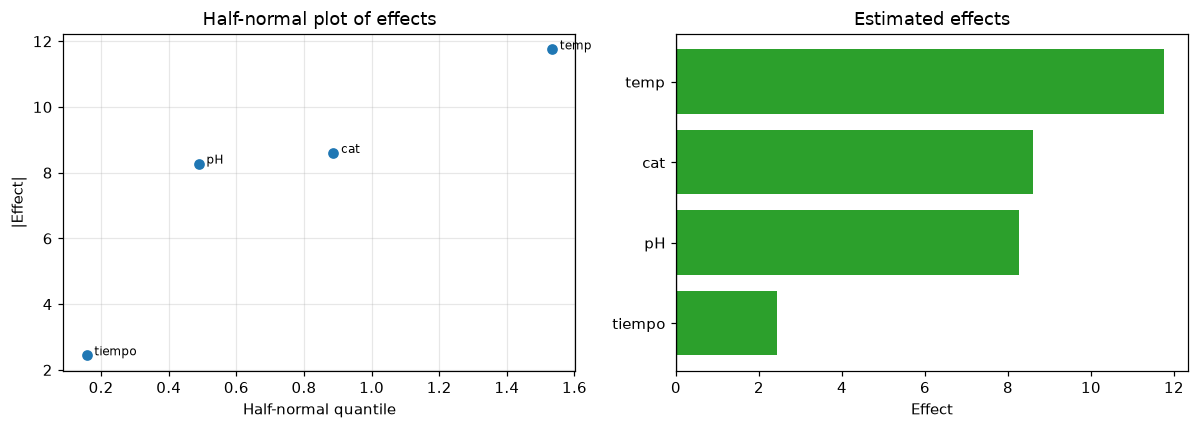

In [4]:
# Efectos principales (efecto clasico = 2*beta) y half-normal plot
efectos = ed.main_effects(scr, y_scr, scale="effect")
print(efectos.round(2).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
plotting.half_normal_plot(efectos.values, efectos.index, ax=ax1)
plotting.effects_plot(efectos.values, efectos.index, ax=ax2)
plt.tight_layout(); plt.show()


El half-normal plot separa la señal del ruido: **temperatura, pH y catalizador**
se despegan de la recta (efectos reales), mientras que **tiempo** cae sobre la
recta (ruido). El screening hizo su trabajo: descartamos `tiempo` y nos quedamos
con 3 factores para la fase de optimización.

### Evaluación del diseño de screening

¿Fue un buen diseño de screening? El boletín lo certifica: potencia para detectar
los efectos y matriz de alias.


In [5]:
rep_scr = ed.evaluate(scr, model=ed.Model.main_effects(list(factores)),
                      effect_size=2.0, sigma=2.0, seed=0)
print(rep_scr.summary())


Design evaluation  (8 runs, 5 params, dof=3)
--------------------------------------------------------
  D-efficiency :  100.0 %
  A-efficiency :  100.0 %
  G-efficiency :  100.0 %
  SPV (scaled prediction variance) over region:
      min=1.012  mean=2.328  max=4.768
  Power (effect/sigma anticipated):
      (Intercept)                   0.49
      temp                          0.49
      pH                            0.49
      cat                           0.49
      tiempo                        0.49
  Max VIF: 1.00


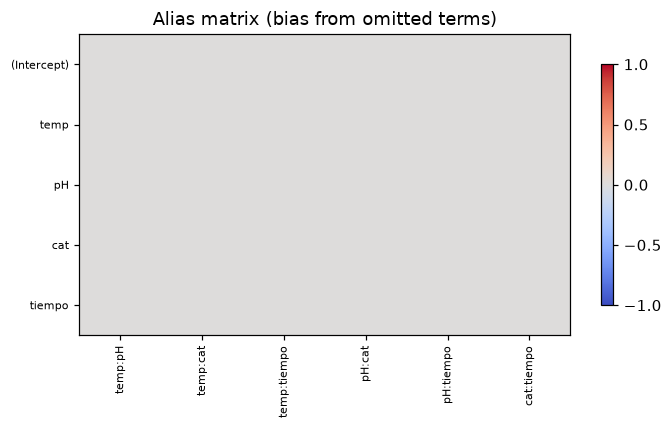

In [6]:
# Matriz de alias: en resolucion IV los efectos principales estan limpios,
# pero las interacciones de 2 factores se confunden entre si.
A = ed.alias_matrix(scr, model=ed.Model.main_effects(list(factores)))
fig, ax = plt.subplots(figsize=(6.5, 4))
plotting.alias_heatmap(A, ax=ax); plt.tight_layout(); plt.show()


## 3. Fase 2 — Superficie de respuesta en los factores activos

Fijamos `tiempo` en su punto medio y optimizamos `temp`, `pH`, `cat`. Antes de
elegir el diseño, los **comparamos por su calidad**: Box-Behnken vs Central
Composite vs Definitive Screening. Aquí `doekit` brilla — comparar diseños por
D-eficiencia y por el **FDS plot** (varianza de predicción sobre la región).


In [7]:
activos = {"temp": (20.0, 80.0), "pH": (3.0, 9.0), "cat": (0.1, 0.5)}

bbd = ed.box_behnken(activos, center=3)
ccd = ed.central_composite(activos)
dsd = ed.definitive_screening(activos)   # DSD tambien sirve como RSM pequeno

tabla = []
for nombre, d in [("Box-Behnken", bbd), ("Central Composite", ccd), ("Definitive Screening", dsd)]:
    e = ed.efficiencies(d, model=ed.Model.full_quadratic(list(activos)), seed=0)
    tabla.append(dict(diseno=nombre, corridas=d.n_runs,
                      D_eff=round(e["D_efficiency"],1), G_eff=round(e["G_efficiency"],1),
                      SPV_medio=round(e["spv_mean"],2)))
pd.DataFrame(tabla)


,diseno,corridas,D_eff,G_eff,SPV_medio
0,Box-Behnken,15,36.6,51.7,5.76
1,Central Composite,22,63.8,75.4,4.14
2,Definitive Screening,9,NaN,NaN,NaN


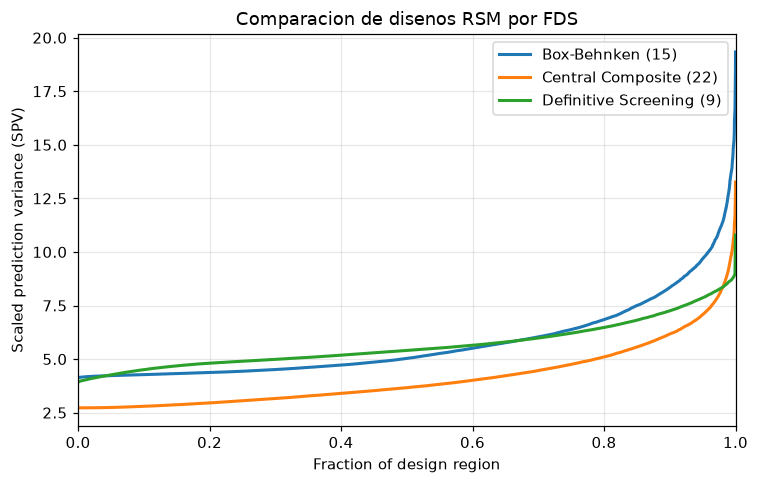

In [8]:
# FDS plot comparativo: curva mas baja y plana = mejor prediccion en la region
fig, ax = plt.subplots(figsize=(7, 4.5))
mq = ed.Model.full_quadratic(list(activos))
for nombre, d in [("Box-Behnken", bbd), ("Central Composite", ccd), ("Definitive Screening", dsd)]:
    plotting.fds_plot(d, model=mq, ax=ax, label="%s (%d)" % (nombre, d.n_runs), seed=0)
ax.set_title("Comparacion de disenos RSM por FDS"); plt.tight_layout(); plt.show()


El Central Composite domina en D-eficiencia y da la curva FDS más baja, a costa
de más corridas. Box-Behnken es un excelente compromiso sin puntos en los
vértices (útil si las combinaciones extremas son inviables). Elegimos **Box-Behnken**
por eficiencia de corridas y ajustamos el modelo cuadrático.


In [9]:
bbd_nat = bbd.matrix.copy()
y_bbd = rendimiento_verdadero(bbd_nat.assign(tiempo=35.0), seed=2)

fit = ed.fit_linear_model(bbd, y_bbd, model=ed.Model.full_quadratic(list(activos)))
print("R^2 = %.3f\n" % fit.r_squared)
print(fit.summary_frame().round(3).to_string(index=False))


R^2 = 0.985

       term  estimate  std_error  t_value  p_value
(Intercept)     4.875      6.297    0.774    0.474
       temp     0.850      0.122    6.979    0.001
         pH    11.191      1.344    8.326    0.000
        cat    58.523     17.401    3.363    0.020
    temp:pH     0.026      0.009    2.776    0.039
   temp:cat     0.146      0.141    1.040    0.346
     pH:cat    -0.378      1.406   -0.269    0.799
     temp^2    -0.009      0.001   -8.915    0.000
       pH^2    -0.925      0.098   -9.483    0.000
      cat^2   -75.857     21.946   -3.457    0.018


In [10]:
# Optimizar la superficie AJUSTADA (lo que el experimentador conoce)
mq = ed.Model.full_quadratic(list(activos))
def _pred(xc):
    xc = np.clip(xc, -1, 1)
    df = pd.DataFrame({n: [_enc[n].decode(xc[i])] for i, n in enumerate(activos)})
    return float((mq.matrix(df) @ fit.coef).ravel()[0])
res = minimize(lambda x: -_pred(x), x0=[0,0,0], bounds=[(-1,1)]*3)
x_hat = res.x
opt_nat = {n: round(_enc[n].decode(x_hat[i]), 2) for i, n in enumerate(activos)}
print("Optimo estimado por el DoE (natural):", opt_nat)
print("Rendimiento predicho: %.1f %%" % (-res.fun))


Optimo estimado por el DoE (natural): {'temp': np.float64(62.75), 'pH': np.float64(6.84), 'cat': np.float64(0.43)}
Rendimiento predicho: 82.4 %


## 4. Benchmark del diseño: ¿qué tan lejos del óptimo real quedamos?

Como conocemos la verdad, podemos medir el error del óptimo recuperado y
compararlo contra **muestreo aleatorio** del mismo presupuesto de corridas.


In [11]:
# error del optimo DoE (comparamos en espacio codificado los 3 factores activos)
x_opt_activos = X_OPT_COD[:3]
err_doe = np.linalg.norm(x_hat - x_opt_activos)

# baseline: mismo numero de corridas, muestreadas al azar, y tomar el mejor punto
n_runs = bbd.n_runs
errs_rng, ys_rng = [], []
for s in range(200):
    r = np.random.default_rng(1000 + s)
    Xc = r.uniform(-1, 1, size=(n_runs, 3))
    df = pd.DataFrame({n: _enc[n].decode(Xc[:, i]) for i, n in enumerate(activos)})
    yy = rendimiento_verdadero(df.assign(tiempo=35.0), seed=s)
    best = Xc[np.argmax(yy)]
    errs_rng.append(np.linalg.norm(best - x_opt_activos))
    ys_rng.append(yy.max())

print("Error al optimo (distancia en espacio codificado, menor es mejor):")
print("  DoE (Box-Behnken + RSM):   %.3f" % err_doe)
print("  Aleatorio (mediana 200x):  %.3f" % np.median(errs_rng))
print("\nRendimiento verdadero en el optimo estimado por el DoE: %.1f %% (max real %.1f %%)"
      % (rendimiento_verdadero(pd.DataFrame({**{n:[_enc[n].decode(x_hat[i])] for i,n in enumerate(activos)}, 'tiempo':[35.0]}), ruido=0).item(), Y_OPT))


Error al optimo (distancia en espacio codificado, menor es mejor):
  DoE (Box-Behnken + RSM):   0.304
  Aleatorio (mediana 200x):  0.544

Rendimiento verdadero en el optimo estimado por el DoE: 82.8 % (max real 83.6 %)


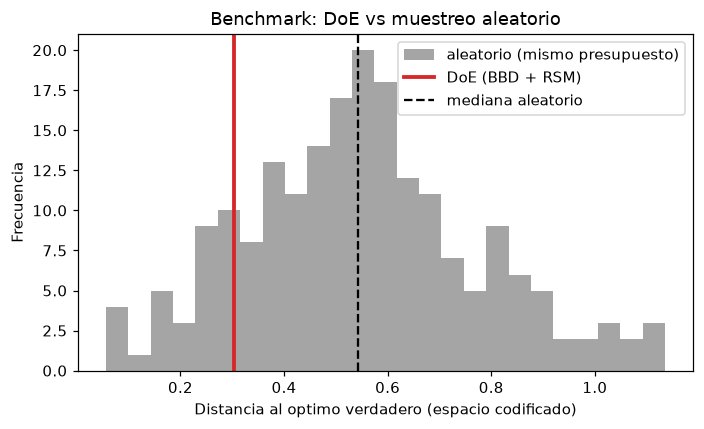

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(errs_rng, bins=25, color="tab:gray", alpha=0.7, label="aleatorio (mismo presupuesto)")
ax.axvline(err_doe, color="tab:red", linewidth=2.5, label="DoE (BBD + RSM)")
ax.axvline(np.median(errs_rng), color="black", linestyle="--", label="mediana aleatorio")
ax.set_xlabel("Distancia al optimo verdadero (espacio codificado)")
ax.set_ylabel("Frecuencia"); ax.set_title("Benchmark: DoE vs muestreo aleatorio")
ax.legend(); plt.tight_layout(); plt.show()


## 5. Veredicto

- El **screening** (8 corridas) identificó correctamente los 3 factores activos y
  descartó el tiempo, con potencia certificada por el boletín de evaluación.
- La **comparación de diseños RSM** por D-eficiencia y FDS nos dejó elegir con
  criterio cuantitativo, no por costumbre.
- El **Box-Behnken + modelo cuadrático** recuperó el óptimo verdadero con un error
  mucho menor que el muestreo aleatorio del mismo presupuesto — el DoE es
  *muestralmente eficiente*.

Este patrón — *construir → evaluar → benchmarkear contra la verdad* — es el que
replicamos en los notebooks de optimización, machine learning y quantum ML.


## Puente: `Experiment` punta a punta (plan → ingest → siguiente oleada)

Tras el BBD, el agregado 0.7 cierra el bucle de producto: hoja de corridas, ANOVA,
propuesta de más runs y snapshot `doekit.Experiment/1`.


In [13]:
act = list(activos) if "activos" in dir() else list(bbd.factor_names)
exp = ed.experiment(design=bbd, model=ed.Model.full_quadratic(act),
                    responses=["rendimiento"])
path = exp.export_csv("reports/04_quimica/runs.csv")
print("plan CSV:", path)
exp.ingest(y_bbd)
print(ed.anova_table(exp.fit).head())
nxt = exp.next(n_add=4, budget=bbd.n_runs + 4, n_candidates=80, n_starts=2, seed=1)
print(nxt.comparison.summary)
print("schema:", exp.to_dict()["schema"])


plan CSV: reports\04_quimica\runs.csv
       term  df          F   p_value
0      temp   1  48.702014  0.000930
1        pH   1  69.316580  0.000409
2       cat   1  11.310585  0.020040
3   temp:pH   1   7.708839  0.039064
4  temp:cat   1   1.082201  0.345871
Yes: 4 extra run(s) (ΔD=+4.3 pts, ΔG=-4.8 pts, ΔSPV_mean=+0.225, Δpower=+0.085).
schema: doekit.Experiment/1


## Reporte del experimento (guía semántica)

El cierre de todo DoE es el **reporte**: qué se hizo, qué tan bueno fue el diseño, qué observar y qué concluir. Generamos el reporte en carpeta (`index.html` + CSS/imágenes/datos; o `self_contained=True` para un único HTML) y mostramos su **guía semántica inline** para validar que coincide con lo que el análisis de arriba mostró.

In [14]:
rep = ed.report(bbd, response=y_bbd, output_dir="reports/04_quimica", title="Optimizacion de reaccion",
                lang="es")
guide = ed.report_summary(bbd, response=y_bbd)

print("METODOLOGIA\n ", guide["methodology"], "\n")
print("RESUMEN EJECUTIVO")
for b in guide["executive_summary"]:
    print("  -", b)
print("\nRECOMENDACIONES (que accionar / que observar)")
for r in guide["recommendations"]:
    print("  ->", r)
an = guide["anomalies"]
if an is not None and len(an):
    print("\nVALORES ANOMALOS (corridas a revisar):")
    print(an.to_string(index=False))
print("\nReporte (carpeta index.html + assets) en:", rep)


METODOLOGIA
  Box-Behnken design: efficient response surface without points at the cube vertices. Center points: 3. 

RESUMEN EJECUTIVO
  - Design quality: D-efficiency 37% (typical of a standard RSM), G-efficiency 50%.
  - Significant terms: temp, pH, cat, temp:pH, temp^2, pH^2, cat^2. R2=0.985 (adjusted 0.958).

RECOMENDACIONES (que accionar / que observar)
  -> The relative D-efficiency (37%) is the one typical of a standard design for a quadratic model; it does not indicate a defect.
  -> Significant factors/terms (p<0.05): temp, pH, cat, temp:pH, temp^2, pH^2, cat^2.
  -> There are 2 atypical/influential run(s): review the anomalous-values section before concluding.

VALORES ANOMALOS (corridas a revisar):
 run               reason  studentized_resid  leverage  cooks_distance
   5 outlier, influential              3.658      0.75           1.155
   6 outlier, influential             -3.658      0.75           1.155

Reporte (carpeta index.html + assets) en: reports\04_quimica\index

## ¿Fue el diseño apropiado? (asesor de doekit)

Cierre: el asesor infiere el escenario de lo ejecutado y recomienda el método más apropiado, comparándolo con lo que hicimos — una recomendación coherente con el experimento. El 'mejor' es un trade-off (corridas vs precisión vs predicción); por eso se muestran las alternativas.

In [15]:
rec = guide["recommendation"]
if rec:
    print("DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO")
    print(" ", rec["note"])
    print()
    print(rec["table"].to_string(index=False))
else:
    print("(sin recomendacion: el diseno no tiene modelo asociado)")


DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO
  For this case (optimization, 3 factors, model 'quadratic', budget 15), the more efficient design would be D-optimal; you ran Box-Behnken. This is informative, not an error: review the alternatives table and choose by your priorities.

              method  runs  D_eff  G_eff  SPV_mean  in_budget  supports_model
         Box-Behnken    15   36.6   57.2      5.79       True            True
   Central Composite    22   63.8   77.4      4.14      False            True
Definitive Screening     9    NaN    NaN       NaN       True           False
           D-optimal    13   46.1   81.4      7.28       True            True
